In [683]:
from ast import literal_eval

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [684]:
df = pd.read_csv("yelp_dataset_csv/yelp_academic_dataset_business.csv")

df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   150346 non-null  str    
 1   name          150346 non-null  str    
 2   address       145219 non-null  str    
 3   city          150346 non-null  str    
 4   state         150346 non-null  str    
 5   postal_code   150273 non-null  str    
 6   latitude      150346 non-null  float64
 7   longitude     150346 non-null  float64
 8   stars         150346 non-null  float64
 9   review_count  150346 non-null  int64  
 10  is_open       150346 non-null  int64  
 11  attributes    136602 non-null  str    
 12  categories    150243 non-null  str    
 13  hours         127123 non-null  str    
dtypes: float64(3), int64(2), str(9)
memory usage: 16.1 MB


,latitude,longitude,stars,review_count,is_open
count,150346.000000,150346.000000,150346.000000,150346.000000,150346.00000
mean,36.671150,-89.357339,3.596724,44.866561,0.79615
std,5.872759,14.918502,0.974421,121.120136,0.40286
min,27.555127,-120.095137,1.000000,5.000000,0.00000
25%,32.187293,-90.357810,3.000000,8.000000,1.00000
50%,38.777413,-86.121179,3.500000,15.000000,1.00000
75%,39.954036,-75.421542,4.500000,37.000000,1.00000
max,53.679197,-73.200457,5.000000,7568.000000,1.00000


In [685]:
df_rest = df[df["categories"].str.contains("Restaurants", na=False)]

df_rest

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,0,"{'Caters': 'True', 'Alcohol': ""u'full_bar'"", '...","Pubs, Restaurants, Italian, Bars, American (Tr...",NaN
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,1,"{'RestaurantsAttire': ""'casual'"", 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '..."
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,1,"{'Alcohol': ""'none'"", 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150325,l9eLGG9ZKpLJzboZq-9LRQ,Wawa,19 N Bishop Ave,Clifton Heights,PA,19018,39.925656,-75.310344,3.0,11,1,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Restaurants, Sandwiches, Convenience Stores, C...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W..."
150327,cM6V90ExQD6KMSU3rRB5ZA,Dutch Bros Coffee,1181 N Milwaukee St,Boise,ID,83704,43.615401,-116.284689,4.0,33,1,"{'WiFi': ""'free'"", 'RestaurantsGoodForGroups':...","Cafes, Juice Bars & Smoothies, Coffee & Tea, R...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-17:0', '..."
150336,WnT9NIzQgLlILjPT0kEcsQ,Adelita Taqueria & Restaurant,1108 S 9th St,Philadelphia,PA,19147,39.935982,-75.158665,4.5,35,1,"{'WheelchairAccessible': 'False', 'Restaurants...","Restaurants, Mexican","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'..."
150339,2O2K6SXPWv56amqxCECd4w,The Plum Pit,4405 Pennell Rd,Aston,DE,19014,39.856185,-75.427725,4.5,14,1,"{'RestaurantsDelivery': 'False', 'BusinessAcce...","Restaurants, Comfort Food, Food, Food Trucks, ...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W..."


In [686]:
df_long = df_rest.assign(categories = df_rest["categories"].str.split(",")).explode("categories")

df_long["categories"] = df_long["categories"].str.strip()


In [687]:
df_clean = df_long[~df_long["categories"].str.contains(r"Restaurants|Food", case=False, na=False)]

cuisine_map = {
    "American": r"burger|american|hot dog|bbq|cajun|southern|cheesesteaks|canadian|pancakes",
    "Italian": r"italian|pizza|pasta|sicilian|sardinian|tuscan|calabrian|roman",
    "Greek": r"greek",
    "East Asian": r"japanese|sushi|ramen|izakaya|teppanyaki|korean|mongolian|chinese|szechuan|dim sum|shanghainese|hong kong style cafe|cantonese|hainan|singaporean|fuzhou|hakka|tonkatsu|donburi|dumplings",
    "Mexican": r"mexican|taco|burrito|tex-mex",
    "French": r"french|bistro",
    "Mediterranean/ Middle Eastern": r"mediterranean|lebanese|turkish|moroccan|middle eastern|falafel|persian|arabic|syrian|afghan|lahmacun|egyptian|uzbek|israeli",
    "Southeast Asian": r"thai|filipino|malaysian|indonesian|pakistani|indian|burmese|laotian|vietnamese|pho|banh mi|nepalese|cambodian|bangladeshi|sri lankan",
    "Asian Fusion": r"asian fusion|pan asian",
    "Pacific Islander": r"hawaiian|poke",
    "Europe": r"europe|irish|ukrainian|modern european|german|portuguese|british|russian|czech|polish|austrian|iberian|scottish|belgian|scandinavian|georgian|hungarian",
    "Caribbean": r"trinidadian|jamaican|cuban|haitian|puerto rican",
    "Latin American": r"latin american|peruvian|argentine|colombian|venezuelan|empanadas|honduran|spanish|dominican|salvadoran|brazilian|nicaraguan",
    "African": r"african|ethiopian|nigerian|senegalese|ghanaian|somali|south african",
    "Oceanian": r"australian"
}

In [688]:
df_clean["major_cuisine"] = "Other"

for cuisine, pattern in cuisine_map.items():
    df_clean.loc[
        df_clean["categories"].str.contains(pattern, case=False, na=False),
        "major_cuisine"
    ] = cuisine

df_cuisine = df_clean[df_clean["major_cuisine"]!="Other"]



In [689]:
df_cuisine_pa = df_cuisine[df_cuisine["state"] == "PA"]

In [690]:
df_cuisine["major_cuisine"]

5                              American
8                               Italian
8                              American
8                                 Greek
9                              American
                      ...              
150313                          Italian
150313                          Italian
150319                         American
150336                          Mexican
150340    Mediterranean/ Middle Eastern
Name: major_cuisine, Length: 61831, dtype: str

In [691]:
cuisine_counts = (df_cuisine.groupby("major_cuisine").size().sort_values(ascending=False).reset_index(name="count"))

In [692]:
cuisine_counts_pa = (df_cuisine_pa.groupby("major_cuisine").size().sort_values(ascending=False).reset_index(name="count") )

In [693]:
cuisine_counts_pa

,major_cuisine,count
0,American,5004
1,Italian,3616
2,East Asian,2245
3,Mexican,978
4,Southeast Asian,925
5,Mediterranean/ Middle Eastern,676
6,Asian Fusion,462
7,Latin American,303
8,Europe,268
9,French,167


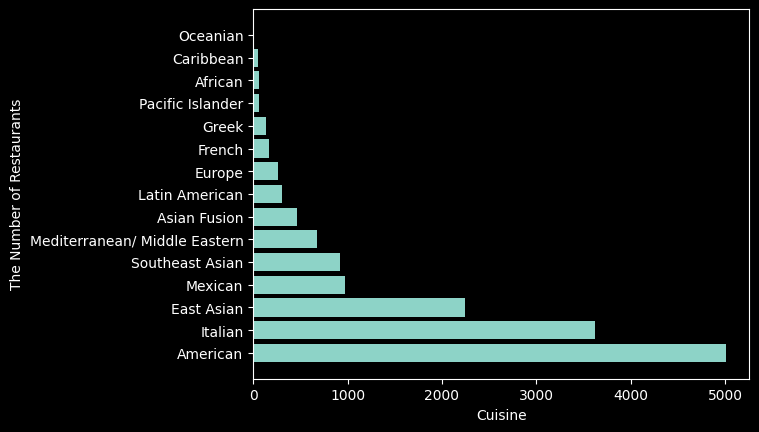

In [694]:
plt.barh(cuisine_counts_pa["major_cuisine"], cuisine_counts_pa["count"])
plt.xlabel("Cuisine")
plt.ylabel("The Number of Restaurants")

plt.show()

In [695]:
cuisine_counts

,major_cuisine,count
0,American,23446
1,Italian,11882
2,East Asian,7931
3,Mexican,6650
4,Southeast Asian,3192
5,Mediterranean/ Middle Eastern,2327
6,Asian Fusion,1616
7,Latin American,1594
8,Europe,878
9,Greek,779


In [696]:
df_rest_american = df[df["categories"].str.contains("American", na=False)]
df_long_american = df_rest_american.assign(categories = df_rest["categories"].str.split(",")).explode("categories")

cuisine_map_except_american = {
    "Italian": r"italian|pizza|pasta|sicilian|sardinian|tuscan|calabrian|roman",
    "Greek": r"greek",
    "East Asian": r"japanese|sushi|ramen|izakaya|teppanyaki|korean|mongolian|chinese|szechuan|dim sum|shanghainese|hong kong style cafe|cantonese|hainan|singaporean|fuzhou|hakka|tonkatsu|donburi|dumplings",
    "Mexican": r"mexican|taco|burrito|tex-mex",
    "French": r"french|bistro",
    "Mediterranean/ Middle Eastern": r"mediterranean|lebanese|turkish|moroccan|middle eastern|falafel|persian|arabic|syrian|afghan|lahmacun|egyptian|uzbek|israeli",
    "Southeast Asian": r"thai|filipino|malaysian|indonesian|pakistani|indian|burmese|laotian|vietnamese|pho|banh mi|nepalese|cambodian|bangladeshi|sri lankan",
    "Asian Fusion": r"asian fusion|pan asian",
    "Pacific Islander": r"hawaiian|poke",
    "Europe": r"europe|irish|ukrainian|modern european|german|portuguese|british|russian|czech|polish|austrian|iberian|scottish|belgian|scandinavian|georgian|hungarian",
    "Caribbean": r"trinidadian|jamaican|cuban|haitian|puerto rican",
    "Latin American": r"latin american|peruvian|argentine|colombian|venezuelan|empanadas|honduran|spanish|dominican|salvadoran|brazilian|nicaraguan",
    "African": r"african|ethiopian|nigerian|senegalese|ghanaian|somali|south african",
    "Oceanian": r"australian"
}

df_long_american["major_cuisine"] = "Other"
for cuisine, pattern in cuisine_map_except_american.items():
    df_long_american.loc[
        df_long_american["categories"].str.contains(pattern, case=False, na=False),
        "major_cuisine"
    ] = cuisine

df_american_fusion = df_long_american[df_long_american["major_cuisine"]!="Other"]
df_american_fusion["major_cuisine"]


8                               Italian
8                                 Greek
58                              Italian
99                              Italian
276                             Mexican
                      ...              
150186    Mediterranean/ Middle Eastern
150201                     Asian Fusion
150201                  Southeast Asian
150201                       East Asian
150210                          Italian
Name: major_cuisine, Length: 5261, dtype: str

In [697]:
american_fusion_counts = (df_american_fusion.groupby("major_cuisine").size().sort_values(ascending=False).reset_index(name="count"))
american_fusion_counts

,major_cuisine,count
0,Italian,1337
1,Latin American,1276
2,Mexican,899
3,Mediterranean/ Middle Eastern,329
4,East Asian,288
5,Europe,283
6,French,192
7,Asian Fusion,188
8,Caribbean,149
9,Greek,143


In [698]:
df_rest.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,0,"{'Caters': 'True', 'Alcohol': ""u'full_bar'"", '...","Pubs, Restaurants, Italian, Bars, American (Tr...",NaN
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,1,"{'RestaurantsAttire': ""'casual'"", 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '..."
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,1,"{'Alcohol': ""'none'"", 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'..."


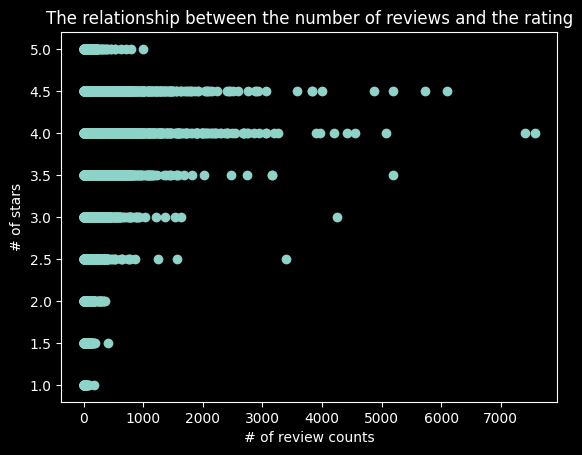

In [699]:
import matplotlib.pyplot as plt

x = df_rest["review_count"]
y = df_rest["stars"]

plt.scatter(x,y)
plt.xlabel("# of review counts")
plt.ylabel("# of stars")
plt.title("The relationship between the number of reviews and the rating")

plt.show()

In [700]:
import ast

In [701]:
df_rest["attributes"] = df_rest["attributes"].apply( lambda x: ast.literal_eval(x) if pd.notnull(x) else {})
attributes = pd.json_normalize(df_rest["attributes"])
df_attributes = pd.concat([df_rest, attributes], axis=1)

df_attributes.drop('AcceptsInsurance', axis=1, inplace=True)


In [702]:
df_attributes.head()


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,GoodForDancing,BestNights,BYOB,Corkage,BYOBCorkage,RestaurantsCounterService,Open24Hours,AgesAllowed,DietaryRestrictions,HairSpecializesIn
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [703]:
def parse_ambience(x):
    if pd.isnull(x):
        return {}
    if isinstance(x, str):
        try:
            parsed =  ast.literal_eval(x)
            return parsed if isinstance(parsed, dict) else {}
        except:
            return {}
    if isinstance(x, dict):
        return x
    return {}

df_ambience = df_attributes["Ambience"].apply(parse_ambience)
ambience = pd.json_normalize(df_ambience.tolist())
df_ambience = pd.concat([df_attributes, ambience], axis=1)

df_ambience.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,HairSpecializesIn,romantic,intimate,touristy,hipster,divey,classy,trendy,upscale,casual
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6.0,...,NaN,False,None,None,None,None,None,None,None,True
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19.0,...,NaN,False,None,False,False,False,False,False,False,True
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10.0,...,NaN,False,False,False,True,NaN,False,True,False,False
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10.0,...,NaN,None,False,False,False,False,None,False,False,True


In [704]:
df_ambience.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,HairSpecializesIn,romantic,intimate,touristy,hipster,divey,classy,trendy,upscale,casual
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6.0,...,NaN,False,None,None,None,None,None,None,None,True
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19.0,...,NaN,False,None,False,False,False,False,False,False,True
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10.0,...,NaN,False,False,False,True,NaN,False,True,False,False
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10.0,...,NaN,None,False,False,False,False,None,False,False,True


In [705]:
df_ambience.drop(columns=["attributes"], inplace=True)



In [706]:
df_ambience.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,HairSpecializesIn,romantic,intimate,touristy,hipster,divey,classy,trendy,upscale,casual
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6.0,...,NaN,False,None,None,None,None,None,None,None,True
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19.0,...,NaN,False,None,False,False,False,False,False,False,True
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10.0,...,NaN,False,False,False,True,NaN,False,True,False,False
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10.0,...,NaN,None,False,False,False,False,None,False,False,True


In [707]:
df_ambience["trendy"].unique()

array([nan, None, False, True], dtype=object)

In [708]:
df_ambience["romantic"].unique()
df_ambience["intimate"].unique()
df_ambience["touristy"].unique()
df_ambience["hipster"].unique()
df_ambience["divey"].unique()
df_ambience["classy"].unique()
df_ambience["upscale"].unique()
df_ambience["casual"].unique()




array([nan, True, False, None], dtype=object)

In [709]:
attributes_values = ["trendy", "intimate", "touristy", "hipster", "divey", "classy", "upscale", "casual"]

for attribute in attributes_values:
    df_ambience[attribute] = df_ambience[attribute].fillna(False)


In [710]:
df_ambience["stars"].unique()



array([4. , 2. , 3. , 1.5, 2.5, 4.5, 3.5, 5. , 1. , nan])

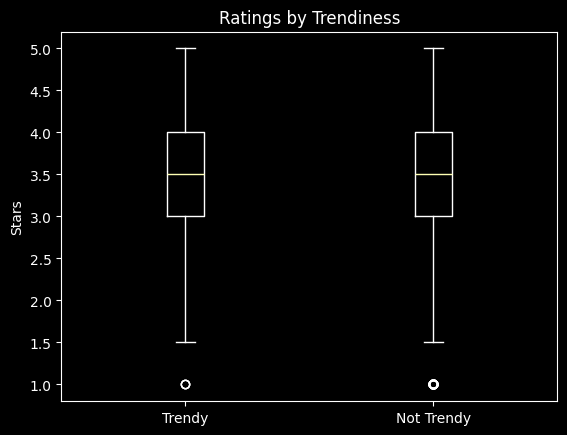

In [711]:
plt.boxplot([
    df_ambience[df_ambience["trendy"] == True]["stars"].dropna(),
    df_ambience[df_ambience["trendy"] == False]["stars"].dropna()
])
plt.xticks([1,2], ["Trendy", "Not Trendy"])
plt.title("Ratings by Trendiness")
plt.ylabel("Stars")
plt.show()

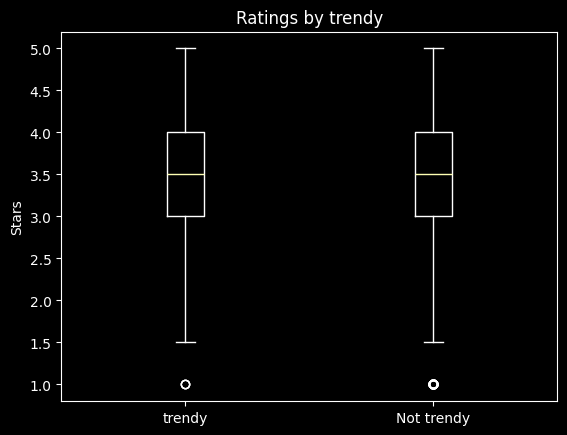

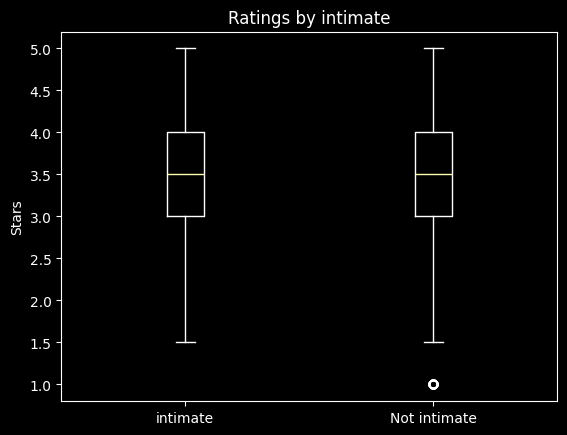

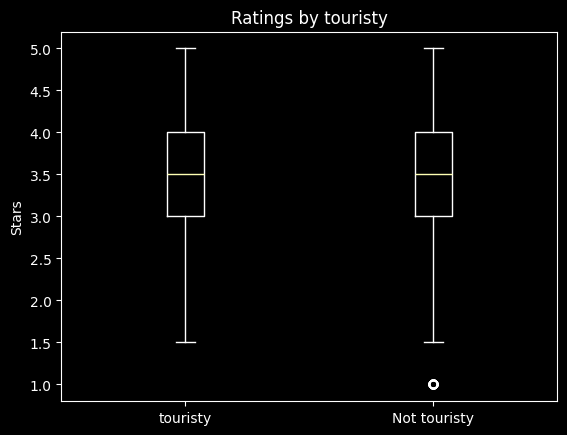

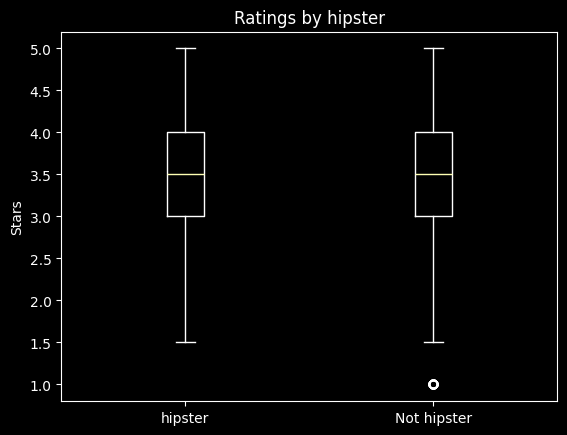

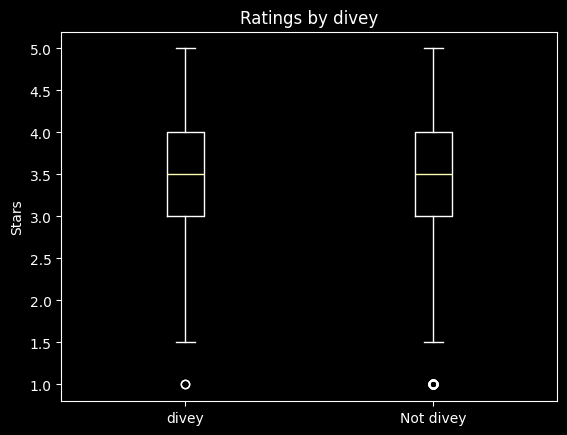

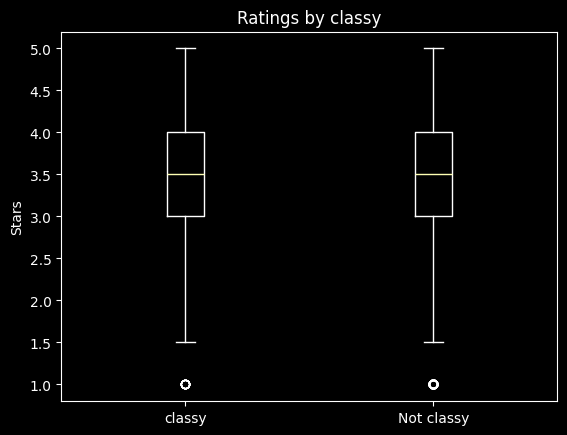

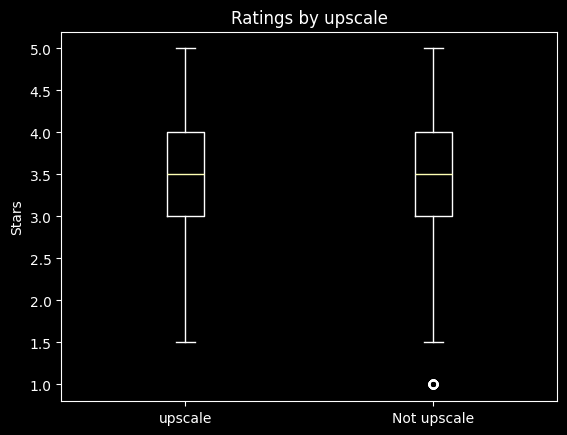

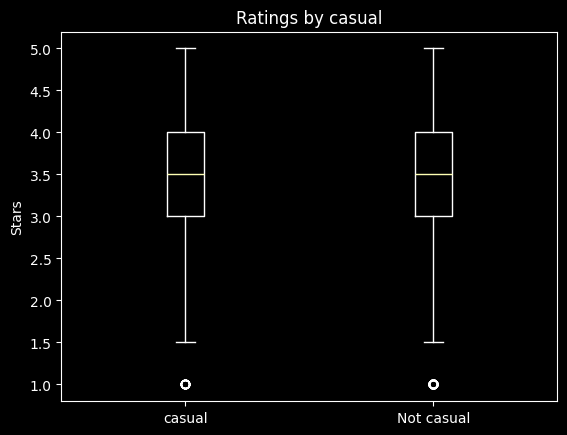

In [712]:
for attribute in attributes_values:
    plt.boxplot([
        df_ambience[df_ambience[attribute] == True]["stars"].dropna(),
        df_ambience[df_ambience[attribute] == False]["stars"].dropna()
    ])
    plt.xticks([1,2], [f"{attribute}", f"Not {attribute}"])
    plt.title(f"Ratings by {attribute}")
    plt.ylabel("Stars")
    plt.show()

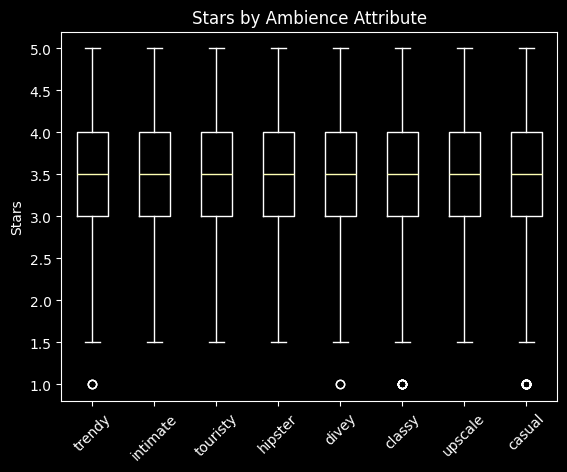

In [713]:
data = []
labels = []
for attribute in attributes_values:
    values = df_ambience[df_ambience[attribute] == True]["stars"].dropna()
    data.append(values)
    labels.append(attribute)

plt.boxplot(data)
plt.xticks(range(1, len(data) + 1), labels, rotation=45)
plt.title("Stars by Ambience Attribute")
plt.ylabel("Stars")
plt.show()


In [714]:
df_attributes.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,GoodForDancing,BestNights,BYOB,Corkage,BYOBCorkage,RestaurantsCounterService,Open24Hours,AgesAllowed,DietaryRestrictions,HairSpecializesIn
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [715]:
attributes_type = ["RestaurantsDelivery", "OutdoorSeating", "BusinessAcceptsCreditCards", "BikeParking", "RestaurantsPriceRange2", "RestaurantsTakeOut", "ByAppointmentOnly", "WiFi", "Alcohol", "Caters", "RestaurantsReservations", "GoodForKids", "CoatCheck", "DogsAllowed", "RestaurantsTableService", "RestaurantsTableService", "RestaurantsGoodForGroups", "WheelchairAccessible", "HasTV", "HappyHour", "DriveThru", "NoiseLevel", "GoodForMeal", "BusinessAcceptsBitcoin", "Smoking", "Music", "GoodForDancing", "BestNights", "BYOB", "Corkage", "BYOBCorkage", "RestaurantsCounterService", "Open24Hours", "AgesAllowed", "DietaryRestrictions"]

for attribute in attributes_type:
    print(df_attributes[attribute].unique())

<StringArray>
['False', 'True', nan, 'None']
Length: 4, dtype: str
<StringArray>
['False', 'True', 'None', nan]
Length: 4, dtype: str
<StringArray>
['False', 'True', nan, 'None']
Length: 4, dtype: str
<StringArray>
['True', 'False', nan, 'None']
Length: 4, dtype: str
<StringArray>
['1', nan, '2', '3', '4', 'None']
Length: 6, dtype: str
<StringArray>
['True', nan, 'None', 'False']
Length: 4, dtype: str
<StringArray>
['False', nan, 'True', 'None']
Length: 4, dtype: str
<StringArray>
['u'free'', 'u'no'', nan, ''free'', ''no'', 'u'paid'', ''paid'', 'None']
Length: 8, dtype: str
<StringArray>
[         'u'none'',      'u'full_bar'',           ''none'',
       ''full_bar'', 'u'beer_and_wine'',                nan,
  ''beer_and_wine'',             'None']
Length: 8, dtype: str
<StringArray>
['True', 'False', nan, 'None']
Length: 4, dtype: str
<StringArray>
[nan, 'False', 'True', 'None']
Length: 4, dtype: str
<StringArray>
[nan, 'True', 'False', 'None']
Length: 4, dtype: str
<StringArray>
[nan,

In [716]:
df_attributes["RestaurantsDelivery"] = df_attributes["RestaurantsDelivery"].map({"True": True, "False": False}).fillna("Unknown")

df_attributes["RestaurantsDelivery"].unique()

array([False, True, 'Unknown'], dtype=object)

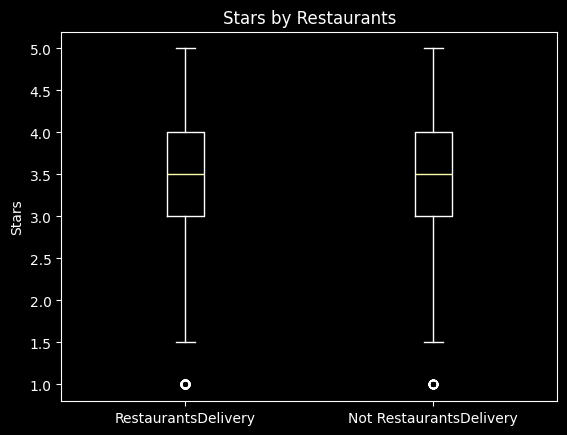

In [717]:
plt.boxplot([
    df_attributes[df_attributes["RestaurantsDelivery"] == True]["stars"],
    df_attributes[df_attributes["RestaurantsDelivery"] == False]["stars"]
])
plt.xticks([1,2], ["RestaurantsDelivery", "Not RestaurantsDelivery"])
plt.title("Stars by Restaurants")
plt.ylabel("Stars")
plt.show()

In [718]:
df_attributes["OutdoorSeating"] = df_attributes["OutdoorSeating"].map({'False': False, 'True': True, 'None': None}).fillna("Unknown")

df_attributes["OutdoorSeating"].unique()

array([False, True, 'Unknown'], dtype=object)

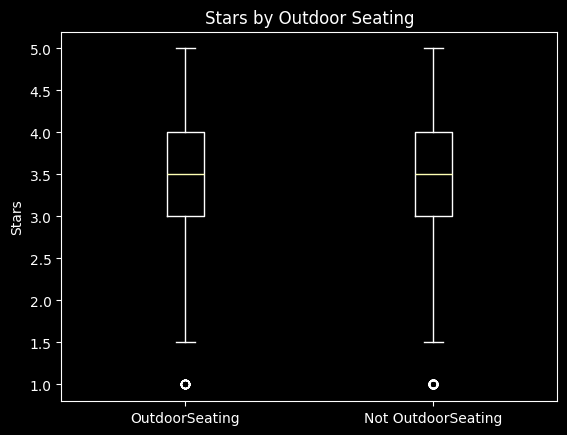

In [719]:
plt.boxplot([
    df_attributes[df_attributes["OutdoorSeating"] == True]["stars"],
    df_attributes[df_attributes["OutdoorSeating"] == False]["stars"]
])
plt.xticks([1,2], ["OutdoorSeating", "Not OutdoorSeating"])
plt.title("Stars by Outdoor Seating")
plt.ylabel("Stars")
plt.show()

In [720]:
df_attributes["BusinessAcceptsCreditCards"] = df_attributes["BusinessAcceptsCreditCards"].map({"True": True, "False": False, "None": None}).fillna("Unknown")

df_attributes["BusinessAcceptsCreditCards"].unique()

array([False, True, 'Unknown'], dtype=object)

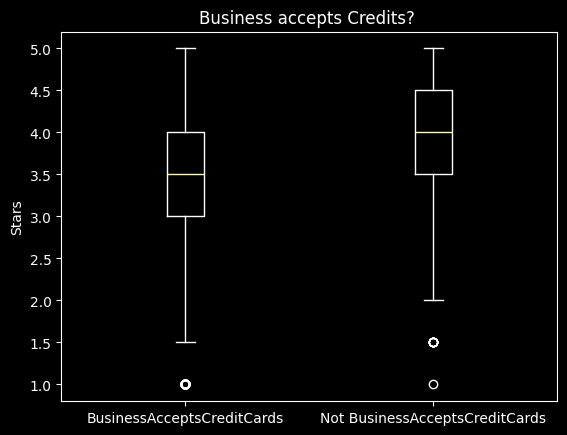

In [721]:
plt.boxplot([
    df_attributes[df_attributes["BusinessAcceptsCreditCards"] == True]["stars"],
    df_attributes[df_attributes["BusinessAcceptsCreditCards"] == False]["stars"]
])
plt.xticks([1,2], ["BusinessAcceptsCreditCards", "Not BusinessAcceptsCreditCards"])
plt.title("Business accepts Credits? ")
plt.ylabel("Stars")
plt.show()

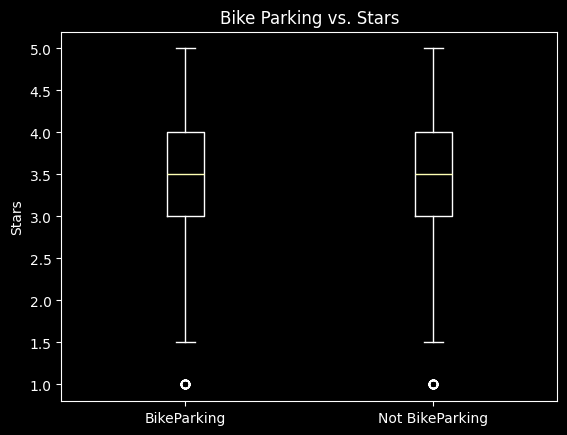

In [722]:
df_attributes["BikeParking"] = df_attributes["BikeParking"].map({"True": True, "False": False, "None": None}).fillna("Unknown")

plt.boxplot([
    df_attributes[df_attributes["BikeParking"] == True]["stars"],
    df_attributes[df_attributes["BikeParking"] == False]["stars"]
])
plt.xticks([1,2], ["BikeParking", "Not BikeParking"])
plt.title("Bike Parking vs. Stars")
plt.ylabel("Stars")
plt.show()

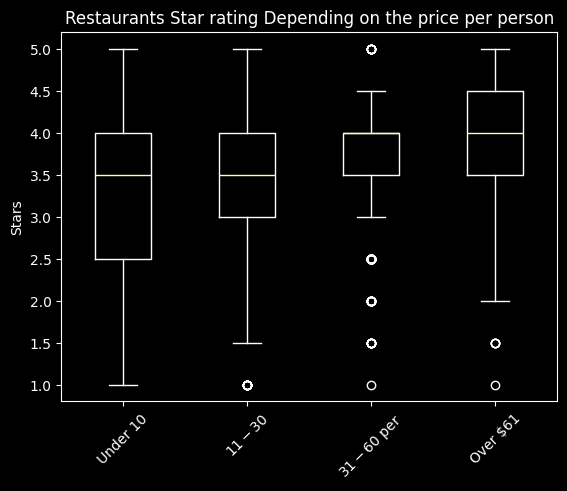

In [723]:
df_attributes["RestaurantsPriceRange2"]= df_attributes["RestaurantsPriceRange2"].map({"None": None, "1": "Under 10 per person", "2": "$11-$30 per person", "3": "$31-$60 per person", "4": "Over $61 per person" }).fillna("Unknown")
plt.boxplot([
    df_attributes[df_attributes["RestaurantsPriceRange2"] == "Under 10 per person"]["stars"],
    df_attributes[df_attributes["RestaurantsPriceRange2"] == "$11-$30 per person"]["stars"],
    df_attributes[df_attributes["RestaurantsPriceRange2"] == "$31-$60 per person"]["stars"],
    df_attributes[df_attributes["RestaurantsPriceRange2"] == "Over $61 per person"]["stars"]


])
plt.xticks([1,2, 3, 4], ["Under 10", "$11-$30", "$31-$60 per", "Over $61"], rotation=45)
plt.title("Restaurants Star rating Depending on the price per person")
plt.ylabel("Stars")
plt.show()

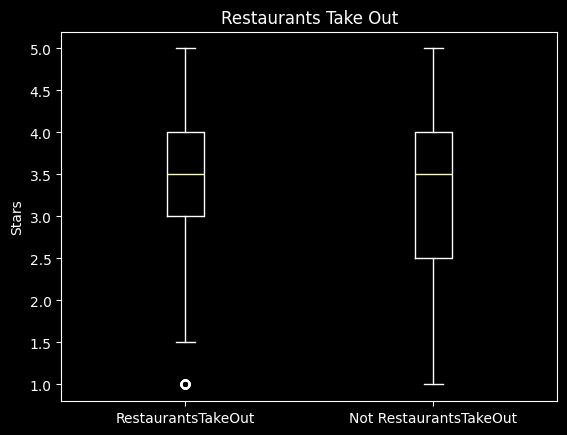

In [724]:
df_attributes["RestaurantsTakeOut"] = df_attributes["RestaurantsTakeOut"].map({"True": True, "False": False, "None": None}).fillna("Unknown")
df_attributes["RestaurantsTakeOut"].unique()
plt.boxplot([
    df_attributes[df_attributes["RestaurantsTakeOut"] == True]["stars"],
    df_attributes[df_attributes["RestaurantsTakeOut"] == False]["stars"]

])
plt.xticks([1,2], ["RestaurantsTakeOut", "Not RestaurantsTakeOut"])
plt.title("Restaurants Take Out")
plt.ylabel("Stars")
plt.show()

In [725]:
df_attributes["ByAppointmentOnly"] = df_attributes["ByAppointmentOnly"].map({"True": True, "False": False, "None": None}).fillna("Unknown")
df_attributes["ByAppointmentOnly"].unique()

array([False, 'Unknown', True], dtype=object)

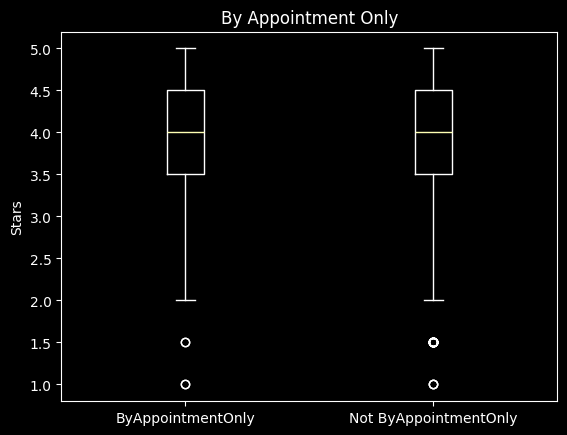

In [726]:
plt.boxplot([
    df_attributes[df_attributes["ByAppointmentOnly"] == True]["stars"],
    df_attributes[df_attributes["ByAppointmentOnly"] == False]["stars"]
])
plt.xticks([1,2], ["ByAppointmentOnly", "Not ByAppointmentOnly"])
plt.title("By Appointment Only")
plt.ylabel("Stars")
plt.show()

In [727]:
df_attributes["WiFi"].unique()
wifi_map = {
    "u'free'": True,
    "'free'": True,
    "free": True,
    "u'paid'": True,
    "'paid'": True,
    "paid": True,
    "u'no'": False,
    "'no'": False,
    "no": False,
    "None": pd.NA
}

df_attributes["WiFi_clean"] = df_attributes["WiFi"].map(wifi_map)

df_wifi_paid = df_attributes[df_attributes["WiFi_clean"] == True]



In [728]:


df_wifi_paid["WiFi_paid"] = \
    (df_wifi_paid["WiFi"]
     .str.replace(r"^u?'", "", regex=True)
     .str.replace(r"'$", "", regex=True)
     )




In [729]:
df_wifi_paid["WiFi_paid"] = df_wifi_paid["WiFi_paid"].map({
    "free": False, "paid": True
})


In [730]:
df_wifi_paid.head()


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,BYOB,Corkage,BYOBCorkage,RestaurantsCounterService,Open24Hours,AgesAllowed,DietaryRestrictions,HairSpecializesIn,WiFi_clean,WiFi_paid
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
15,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
20,WKMJwqnfZKsAae75RMP6jA,Roast Coffeehouse and Wine Bar,10359 104 Street NW,Edmonton,AB,T5J 1B9,53.546045,-113.499169,4.0,40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
23,9OG5YkX1g2GReZM0AskizA,Romano's Macaroni Grill,5505 S Virginia St,Reno,NV,89502,39.476117,-119.789339,2.5,339,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False


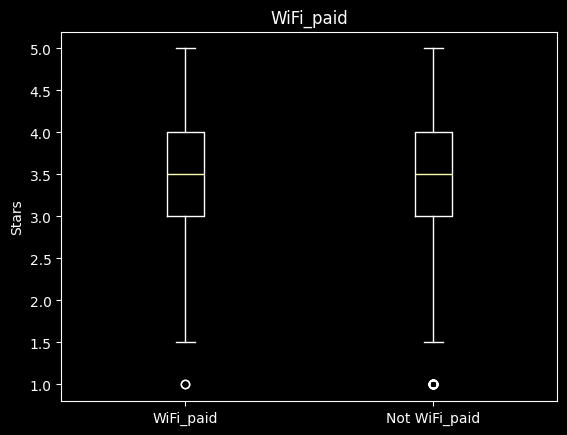

In [731]:

plt.boxplot([
    df_wifi_paid[df_wifi_paid["WiFi_paid"] == True]["stars"],
    df_wifi_paid[df_wifi_paid["WiFi_paid"] == False]["stars"]
])
plt.xticks([1,2], ["WiFi_paid", "Not WiFi_paid"])
plt.title("WiFi_paid")
plt.ylabel("Stars")
plt.show()

In [732]:
df_attributes["Alcohol"].unique()

<StringArray>
[         'u'none'',      'u'full_bar'',           ''none'',
       ''full_bar'', 'u'beer_and_wine'',                nan,
  ''beer_and_wine'',             'None']
Length: 8, dtype: str

In [733]:
alcohol_rule = {
    "u'none'": False,
    "u'full_bar'": True,
    "'none'": "Unknown",
    "'full_bar'": True,
    "u'beer_and_wine'": True,
    "'beer_and_wine'": True,
    "None": "Unknown",
    pd.NA: "Unknown"
}

df_attributes["Alcohol_clean"] = df_attributes["Alcohol"].map(alcohol_rule)

df_attributes["Alcohol_clean"].unique()

array([False, True, 'Unknown'], dtype=object)

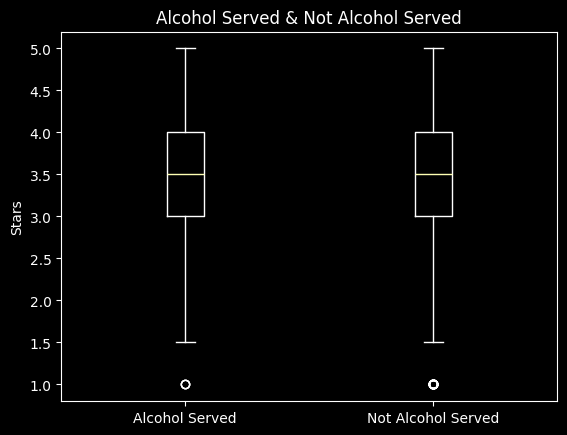

In [734]:
plt.boxplot([
    df_attributes[df_attributes["Alcohol_clean"] == True]["stars"],
    df_attributes[df_attributes["Alcohol_clean"] == False]["stars"]
])
plt.xticks([1,2], ["Alcohol Served", "Not Alcohol Served"])
plt.title("Alcohol Served & Not Alcohol Served")
plt.ylabel("Stars")
plt.show()

In [735]:
df_alcohol_type = df_attributes[df_attributes['Alcohol_clean'] == True]

df_alcohol_type["Alcohol_type"] = \
    (df_attributes['Alcohol']
    .str.replace(r"^u?'", "", regex=True)
    .str.replace(r"'$", "", regex=True)
     )

df_alcohol_type["Alcohol_type"].unique()


<StringArray>
['full_bar', 'beer_and_wine']
Length: 2, dtype: str

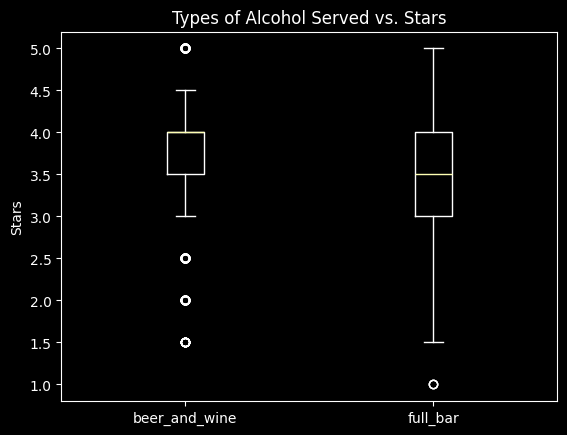

In [736]:
plt.boxplot([
    df_alcohol_type[df_alcohol_type["Alcohol_type"] == "beer_and_wine"]["stars"],
    df_alcohol_type[df_alcohol_type["Alcohol_type"] == "full_bar"]["stars"]
])
plt.xticks([1,2], ["beer_and_wine", "full_bar"])
plt.title("Types of Alcohol Served vs. Stars")
plt.ylabel("Stars")
plt.show()

In [737]:
df_attributes["Caters"] = df_attributes["Caters"].map({"True": True, "False": False, "None": None}).fillna("Unknown")

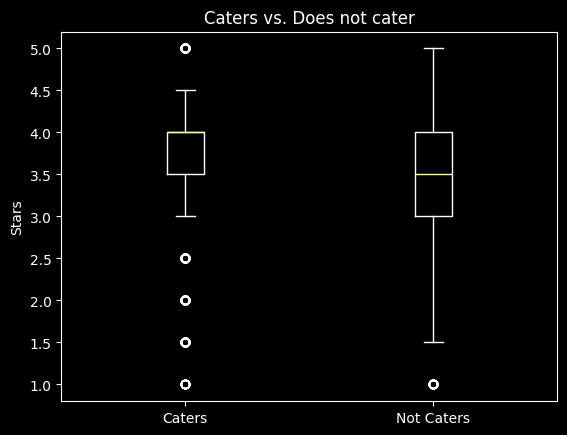

In [738]:
plt.boxplot([
    df_attributes[df_attributes["Caters"] == True]["stars"],
    df_attributes[df_attributes["Caters"] == False]["stars"]
])
plt.xticks([1,2], ["Caters", "Not Caters"])
plt.title("Caters vs. Does not cater")
plt.ylabel("Stars")
plt.show()

In [739]:
df_attributes["RestaurantsReservations"] = df_attributes["RestaurantsReservations"].map({"False": False, "True": True, "None": None}).fillna("Unknown")

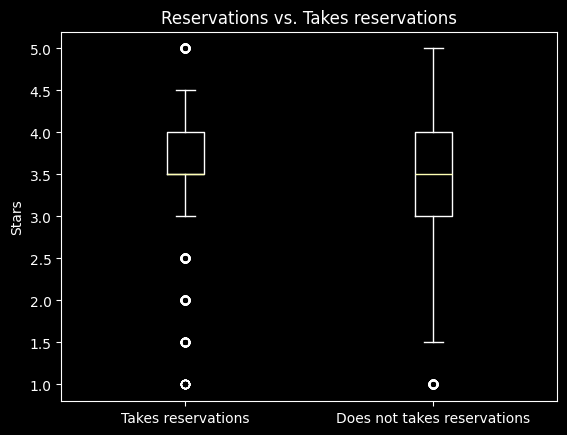

In [740]:
plt.boxplot([
    df_attributes[df_attributes["RestaurantsReservations"] == True]["stars"],
    df_attributes[df_attributes["RestaurantsReservations"] == False]["stars"]
])
plt.xticks([1,2], ["Takes reservations", "Does not takes reservations"])
plt.title("Reservations vs. Takes reservations")
plt.ylabel("Stars")
plt.show()


In [741]:
df_attributes["GoodForKids"] = df_attributes["GoodForKids"].map({"True": True, "False": False, "None": None}).fillna("Unknown")

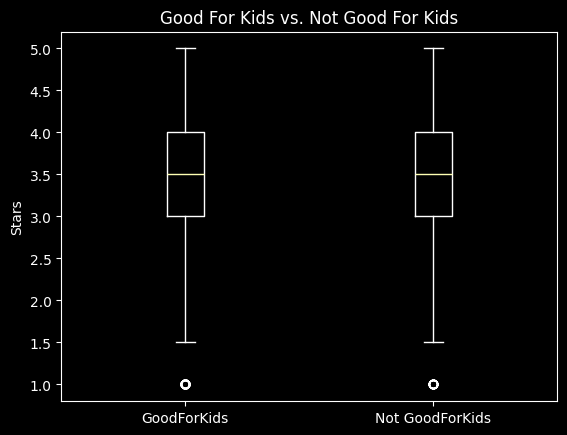

In [742]:
plt.boxplot([
    df_attributes[df_attributes["GoodForKids"] == True]["stars"],
    df_attributes[df_attributes["GoodForKids"] == False]["stars"]
])
plt.xticks([1,2], ["GoodForKids", "Not GoodForKids"])
plt.title("Good For Kids vs. Not Good For Kids")
plt.ylabel("Stars")
plt.show()

In [743]:
df_attributes["CoatCheck"].unique()

<StringArray>
[nan, 'False', 'True', 'None']
Length: 4, dtype: str

In [744]:
df_attributes["CoatCheck"] = df_attributes["CoatCheck"].map({
    "True": True, "False": False, "None": None
})

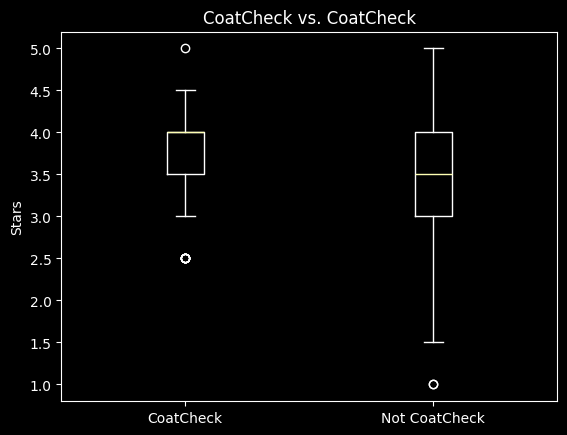

In [745]:
plt.boxplot([
    df_attributes[df_attributes["CoatCheck"] == True]["stars"],
    df_attributes[df_attributes["CoatCheck"] == False]["stars"]
])
plt.xticks([1,2], ["CoatCheck", "Not CoatCheck"])
plt.title("CoatCheck vs. CoatCheck")
plt.ylabel("Stars")
plt.show()

In [746]:
df_attributes["DogsAllowed"].unique()

<StringArray>
[nan, 'False', 'True', 'None']
Length: 4, dtype: str

In [747]:
df_attributes["DogsAllowed"] = df_attributes["DogsAllowed"].map({"True": True, "False": False, "None": None}).fillna("Unknown")

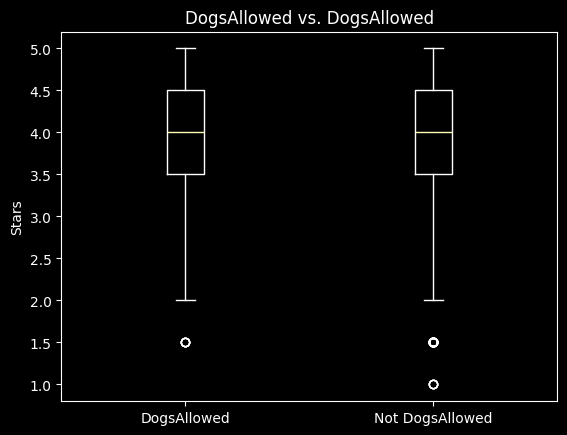

In [748]:
plt.boxplot([
    df_attributes[df_attributes["DogsAllowed"] == True]["stars"],
    df_attributes[df_attributes["DogsAllowed"] == False]["stars"]
])
plt.xticks([1,2], ["DogsAllowed", "Not DogsAllowed"])
plt.title("DogsAllowed vs. DogsAllowed")
plt.ylabel("Stars")
plt.show()

In [749]:
df_attributes["RestaurantsTableService"] = df_attributes["RestaurantsTableService"].map({"True": True, "False": False, "None": None}).fillna("Unknown")

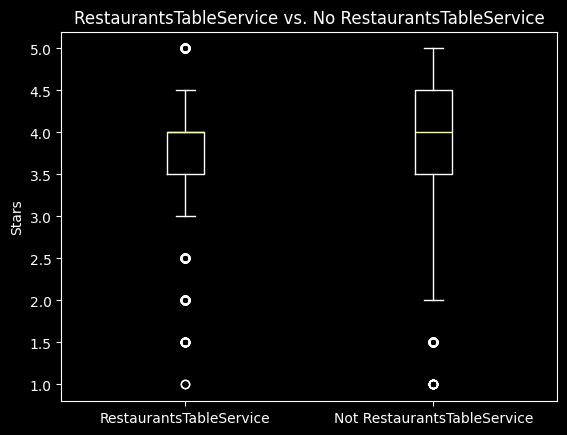

In [750]:
plt.boxplot([
    df_attributes[df_attributes["RestaurantsTableService"] == True]["stars"],
    df_attributes[df_attributes["RestaurantsTableService"] == False]["stars"]
])
plt.xticks([1,2], ["RestaurantsTableService", "Not RestaurantsTableService"])
plt.title("RestaurantsTableService vs. No RestaurantsTableService")
plt.ylabel("Stars")
plt.show()

In [751]:
df_attributes["RestaurantsGoodForGroups"].unique()

<StringArray>
[nan, 'True', 'False', 'None']
Length: 4, dtype: str

In [752]:
df_attributes["RestaurantsGoodForGroups"] = df_attributes["RestaurantsGoodForGroups"].map({"True": True, "False": False, "None": None}).fillna("Unknown")


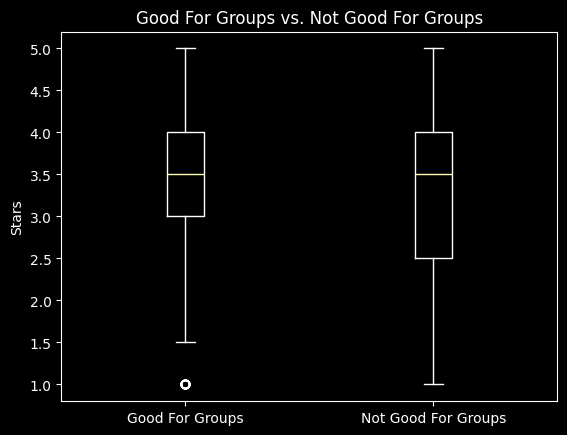

In [753]:
plt.boxplot([
    df_attributes[df_attributes["RestaurantsGoodForGroups"] == True]["stars"],
    df_attributes[df_attributes["RestaurantsGoodForGroups"] == False]["stars"]]
            )
plt.xticks([1,2], ["Good For Groups", "Not Good For Groups"])
plt.title("Good For Groups vs. Not Good For Groups")
plt.ylabel("Stars")
plt.show()

In [754]:
df_attributes["WheelchairAccessible"].map({"True": True, "False": False, "None": None}).fillna("Unknown")

3         Unknown
5            True
8         Unknown
9            True
11        Unknown
           ...   
150325    Unknown
150327    Unknown
150336      False
150339       True
150340    Unknown
Name: WheelchairAccessible, Length: 52268, dtype: object

In [755]:
parser = {"True": True, "False": False, "None": None}

df_attributes["HasTV"] = df_attributes["HasTV"].map(parser).fillna("Unknown")

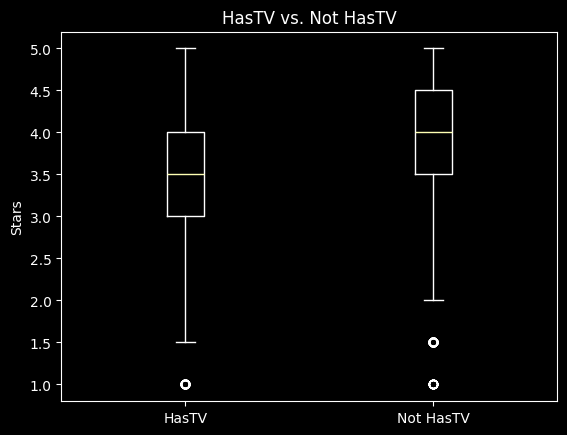

In [756]:
plt.boxplot([
    df_attributes[df_attributes["HasTV"] == True]["stars"],
    df_attributes[df_attributes["HasTV"] == False]["stars"]
])
plt.xticks([1,2], ["HasTV", "Not HasTV"])
plt.title("HasTV vs. Not HasTV")
plt.ylabel("Stars")
plt.show()


In [757]:
df_attributes["HappyHour"] = df_attributes["HappyHour"].map(parser).fillna("Unknown")

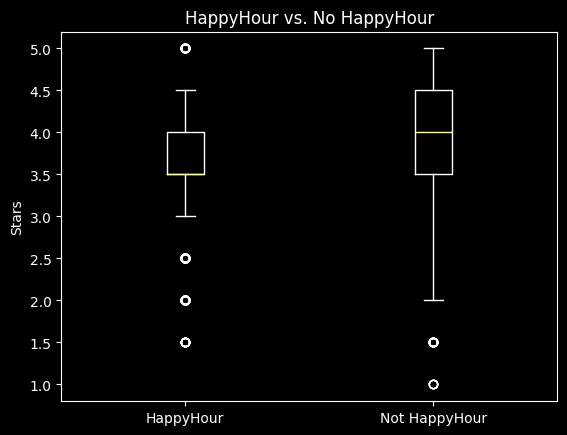

In [758]:
plt.boxplot([
    df_attributes[df_attributes["HappyHour"] == True]["stars"],
    df_attributes[df_attributes["HappyHour"] == False]["stars"]
])
plt.xticks([1,2], ["HappyHour", "Not HappyHour"])
plt.title("HappyHour vs. No HappyHour")
plt.ylabel("Stars")
plt.show()

In [759]:
df_attributes["DriveThru"] = df_attributes["DriveThru"].map(parser).fillna("Unknown")

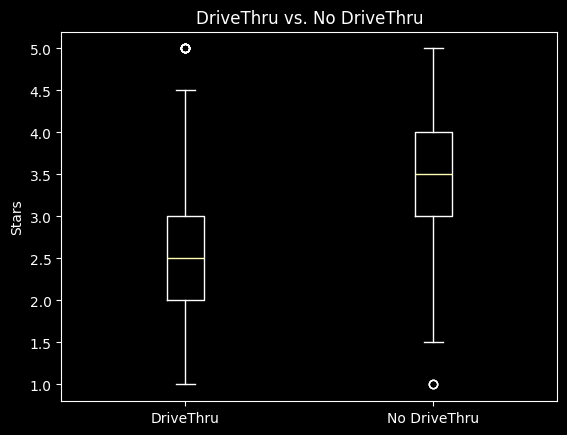

In [760]:
plt.boxplot([
    df_attributes[df_attributes["DriveThru"] == True]["stars"],
    df_attributes[df_attributes["DriveThru"] == False]["stars"]
])
plt.xticks([1,2], ["DriveThru", "No DriveThru"])
plt.title("DriveThru vs. No DriveThru")
plt.ylabel("Stars")
plt.show()

In [761]:
df_attributes["NoiseLevel"].unique()

<StringArray>
[           nan,   'u'average'',     'u'quiet'',    ''average'',
      'u'loud'', 'u'very_loud'',      ''quiet'',  ''very_loud'',
       ''loud'',         'None']
Length: 10, dtype: str

In [762]:
df_attributes["NoiseLevel"] = \
    (df_attributes["NoiseLevel"]
    .str.replace("^u?'","", regex=True)
    .str.replace("'$", "", regex=True)
    .str.replace("'", "", regex=True)
    .replace("None", None))

df_attributes["NoiseLevel"].unique()


<StringArray>
[nan, 'average', 'quiet', 'loud', 'very_loud']
Length: 5, dtype: str

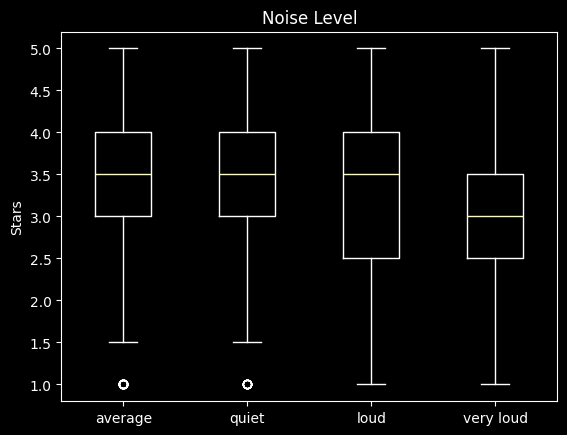

In [763]:
plt.boxplot([
    df_attributes[df_attributes["NoiseLevel"] == "average"]["stars"],
    df_attributes[df_attributes["NoiseLevel"] == "quiet"]["stars"],
    df_attributes[df_attributes["NoiseLevel"] == "loud"]["stars"],
    df_attributes[df_attributes["NoiseLevel"] == "very_loud"]["stars"],
])
plt.xticks([1,2,3,4], ["average", "quiet", "loud", "very loud"])
plt.title("Noise Level")
plt.ylabel("Stars")
plt.show()

In [764]:
def clean_meals(x):
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return x
    try:
        x = x.replace("u'", "'")
        return ast.literal_eval(x)
    except:
        return {}
    return {}


df_attributes["Meals_type"] = df_attributes['GoodForMeal'].apply(clean_meals).apply(lambda x: x if isinstance(x, dict) else {})

meals_type = pd.json_normalize(df_attributes["Meals_type"])
df_meal_type = pd.concat([df_attributes, meals_type], axis=1)
df_meal_type.head()


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,HairSpecializesIn,WiFi_clean,Alcohol_clean,Meals_type,dessert,latenight,lunch,dinner,brunch,breakfast
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,NaN,True,False,{},NaN,NaN,NaN,NaN,NaN,NaN
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,...,NaN,False,False,{},NaN,NaN,NaN,NaN,NaN,NaN
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,...,NaN,True,True,{},NaN,NaN,NaN,NaN,NaN,NaN
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,...,NaN,False,False,{},NaN,NaN,NaN,NaN,NaN,NaN
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,...,NaN,NaN,Unknown,"{'dessert': False, 'latenight': False, 'lunch'...",False,False,False,False,False,False


In [765]:
meal_types = ["dessert", "latenight", "lunch", "dinner", "brunch", "breakfast"]

for meal_type in meal_types:
    df_meal_type[meal_type] = df_meal_type[meal_type].fillna("Unknown")



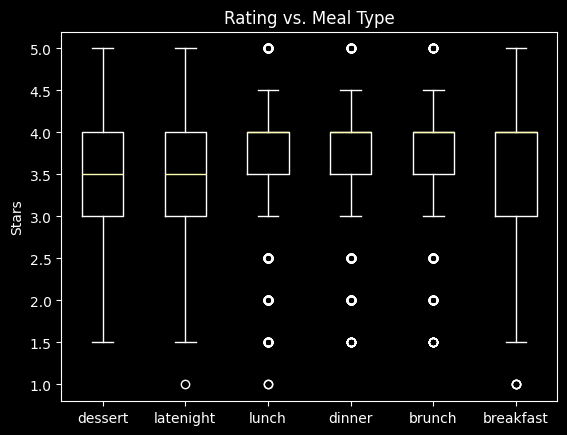

In [766]:
data = []
for meal_type in meal_types:
    temp = df_meal_type[df_meal_type[meal_type] == True]["stars"]
    data.append(temp)

plt.boxplot(data)
plt.xticks([1,2,3,4,5,6], meal_types)
plt.title("Rating vs. Meal Type")
plt.ylabel("Stars")
plt.show()

In [767]:
df_attributes["BusinessAcceptsBitcoin"] = df_attributes["BusinessAcceptsBitcoin"].map(parser).fillna("Unknown")

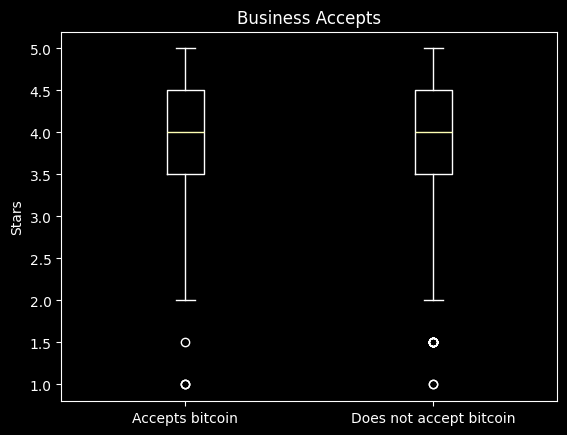

In [768]:
plt.boxplot(
    [
        df_attributes[df_attributes["BusinessAcceptsBitcoin"] == True]["stars"],
        df_attributes[df_attributes["BusinessAcceptsBitcoin"] == False]["stars"]
    ]
)
plt.xticks([1,2],["Accepts bitcoin", "Does not accept bitcoin"])
plt.title("Business Accepts")
plt.ylabel("Stars")
plt.show()

In [769]:
df_attributes["Open24Hours"] = df_attributes["Open24Hours"].map(parser).fillna("Unknown")

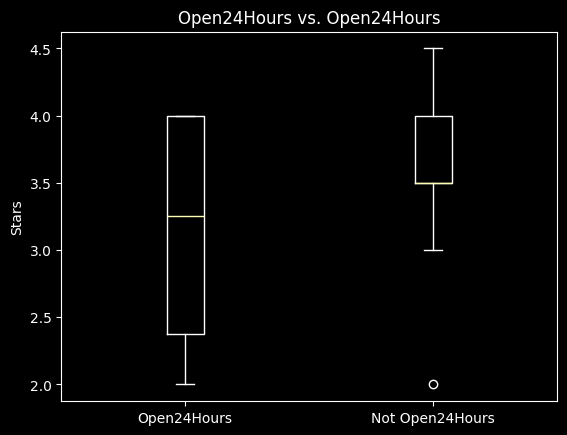

In [770]:
plt.boxplot([
    df_attributes[df_attributes["Open24Hours"] == True]["stars"],
    df_attributes[df_attributes["Open24Hours"] == False]["stars"]
])
plt.xticks([1,2], ["Open24Hours", "Not Open24Hours"])
plt.title("Open24Hours vs. Open24Hours")
plt.ylabel("Stars")
plt.show()

In [771]:
def parse_music(x):
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return {}
    return {}

df_attributes["Music"] = df_attributes["Music"].apply(parse_music).apply(lambda x: x if isinstance(x, dict) else {})
music_attributes = pd.json_normalize(df_attributes["Music"])
df_music_type = pd.concat([df_attributes, music_attributes], axis=1)

df_music_type.head()



,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,WiFi_clean,Alcohol_clean,Meals_type,dj,background_music,no_music,jukebox,live,video,karaoke
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,True,False,{},NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,...,False,False,{},NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,...,True,True,{},NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,...,False,False,{},NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,...,NaN,Unknown,"{'dessert': False, 'latenight': False, 'lunch'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


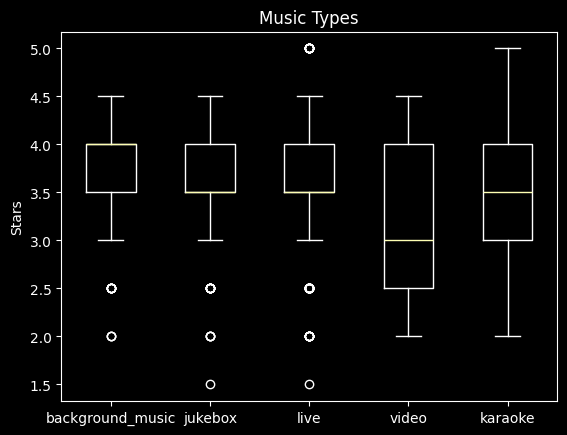

In [772]:
music_types = ["background_music", "jukebox", "live", "video", "karaoke"]

data = []
for music_type in music_types:
    temp = df_music_type[df_music_type[music_type] == True]["stars"]
    data.append(temp)

plt.boxplot(data)
plt.xticks([1,2,3,4,5], music_types)
plt.title("Music Types")
plt.ylabel("Stars")
plt.show()

In [773]:
df_attributes["BestNights"] = df_attributes["BestNights"].apply(clean_meals).apply(lambda x: x if isinstance(x, dict) else {})

best_days_nights = pd.json_normalize(df_attributes["BestNights"])

df_best_days_nights = pd.concat([df_attributes, best_days_nights], axis=1)

df_best_days_nights.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,WiFi_clean,Alcohol_clean,Meals_type,monday,tuesday,friday,wednesday,thursday,sunday,saturday
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,True,False,{},NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,...,False,False,{},NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,...,True,True,{},NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,...,False,False,{},NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,...,NaN,Unknown,"{'dessert': False, 'latenight': False, 'lunch'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [774]:
df_best_days_nights["monday"].unique()

array([nan, False, True], dtype=object)

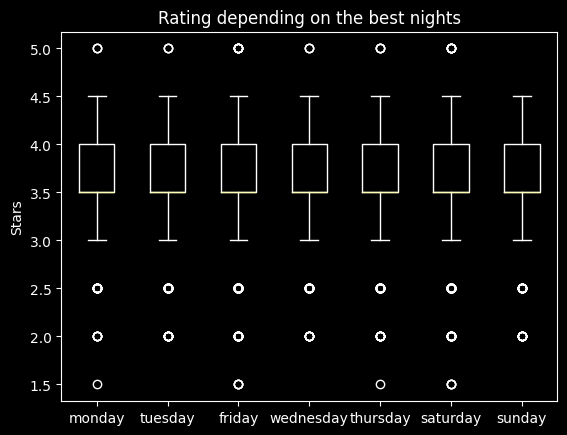

In [775]:
days = ["monday", "tuesday", "friday", "wednesday", "thursday", "saturday", "sunday"]

data = []
for day in days:
    temp = df_best_days_nights[df_best_days_nights[day]==True]["stars"]
    data.append(temp)

plt.boxplot(data)
plt.xticks([1,2,3,4,5,6,7], days)
plt.title("Rating depending on the best nights")
plt.ylabel("Stars")
plt.show()


In [776]:
states = df["state"].unique().tolist()

states

['CA',
 'MO',
 'AZ',
 'PA',
 'TN',
 'FL',
 'IN',
 'LA',
 'AB',
 'NV',
 'ID',
 'DE',
 'IL',
 'NJ',
 'NC',
 'CO',
 'WA',
 'HI',
 'UT',
 'TX',
 'MT',
 'MI',
 'SD',
 'XMS',
 'MA',
 'VI',
 'VT']

In [777]:
state_reviews = df_rest.groupby("state")["review_count"].sum().sort_values(ascending=False).reset_index()

print(state_reviews)


   state  review_count
0     PA       1060906
1     FL        763837
2     LA        544962
3     TN        423749
4     MO        341270
5     IN        323905
6     AZ        255336
7     NV        232037
8     CA        206222
9     NJ        163692
10    ID         96521
11    AB         66398
12    DE         47055
13    IL         35320
14    NC            29
15    HI            17
16    CO            12
17    MT             6
18   XMS             5


In [778]:
df_cuisine_pa.to_csv("cleaned_dataset/pa_major_cuisine.csv", index=False)
df_attributes.to_csv("cleaned_dataset/attributes_rest.csv", index=False)
df_meal_type.to_csv("cleaned_dataset/meal_types_rest.csv", index=False)
df_music_type.to_csv("cleaned_dataset/music_types_rest.csv", index=False)
df_alcohol_type.to_csv("cleaned_dataset/alcohol_types_rest.csv", index=False)
df_wifi_paid.to_csv("cleaned_dataset/wifi_paid.csv", index=False)
df_ambience.to_csv("cleaned_dataset/ambience.csv", index=False)
df_best_days_nights.to_csv("cleaned_dataset/best_days_nights.csv", index=False)

In [779]:
df_meal_type.drop("Meals_type", axis=1, inplace=True)

In [780]:
df_attributes.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,Corkage,BYOBCorkage,RestaurantsCounterService,Open24Hours,AgesAllowed,DietaryRestrictions,HairSpecializesIn,WiFi_clean,Alcohol_clean,Meals_type
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,True,False,{}
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,...,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,False,False,{}
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,...,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,True,True,{}
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,...,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,False,False,{}
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,...,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,Unknown,"{'dessert': False, 'latenight': False, 'lunch'..."


In [781]:
df_meal_type.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,DietaryRestrictions,HairSpecializesIn,WiFi_clean,Alcohol_clean,dessert,latenight,lunch,dinner,brunch,breakfast
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,NaN,NaN,True,False,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,...,NaN,NaN,False,False,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,...,NaN,NaN,True,True,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,...,NaN,NaN,False,False,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,...,NaN,NaN,NaN,Unknown,False,False,False,False,False,False


In [782]:
df_cuisine_pa.head()

def making_copies():
    copies = []
    df_cuisine_pa_copy = df_cuisine[["business_id", "major_cuisine"]].copy()
    copies.append(df_cuisine_pa_copy)
    df_ambience_copy = df_ambience[["business_id", "trendy", "romantic", "intimate", "touristy", "hipster", "divey", "classy", "upscale", "casual"]].copy()
    copies.append(df_ambience_copy)
    df_meal_type_copy = df_meal_type[["business_id", "dessert", "latenight", "lunch", "dinner", "brunch", "breakfast"]].copy()
    copies.append(df_meal_type_copy)
    df_music_type_copy_1 = df_music_type[["business_id", "background_music", "jukebox", "live", "video", "karaoke"]].copy()
    copies.append(df_music_type_copy_1)
    df_alcohol_type_copy = df_alcohol_type[["business_id", "Alcohol_type"]]
    copies.append(df_alcohol_type_copy)

    return copies






In [783]:
df_map = None
for copy in making_copies():
    df_map = pd.merge(df_attributes, copy, left_on="business_id", right_on="business_id", how="inner")


In [784]:
df_map.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,BYOBCorkage,RestaurantsCounterService,Open24Hours,AgesAllowed,DietaryRestrictions,HairSpecializesIn,WiFi_clean,Alcohol_clean,Meals_type,Alcohol_type
0,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,...,NaN,NaN,Unknown,NaN,NaN,NaN,True,True,{},full_bar
1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,...,NaN,NaN,Unknown,NaN,NaN,NaN,True,True,"{'dessert': True, 'latenight': None, 'lunch': ...",full_bar
2,WKMJwqnfZKsAae75RMP6jA,Roast Coffeehouse and Wine Bar,10359 104 Street NW,Edmonton,AB,T5J 1B9,53.546045,-113.499169,4.0,40,...,NaN,NaN,Unknown,NaN,NaN,NaN,True,True,{},beer_and_wine
3,9OG5YkX1g2GReZM0AskizA,Romano's Macaroni Grill,5505 S Virginia St,Reno,NV,89502,39.476117,-119.789339,2.5,339,...,NaN,NaN,Unknown,NaN,NaN,NaN,True,True,"{'dessert': None, 'latenight': False, 'lunch':...",full_bar
4,4iRzR7OaS-QaSXuvYxEGKA,Super Dog,1160 Gallatin Pike S,Nashville,TN,37115,36.248570,-86.719986,4.0,6,...,NaN,NaN,Unknown,NaN,NaN,NaN,False,True,{},beer_and_wine


In [785]:
df_map.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'RestaurantsDelivery',
       'OutdoorSeating', 'BusinessAcceptsCreditCards', 'BusinessParking',
       'BikeParking', 'RestaurantsPriceRange2', 'RestaurantsTakeOut',
       'ByAppointmentOnly', 'WiFi', 'Alcohol', 'Caters', 'RestaurantsAttire',
       'RestaurantsReservations', 'Ambience', 'GoodForKids', 'CoatCheck',
       'DogsAllowed', 'RestaurantsTableService', 'RestaurantsGoodForGroups',
       'WheelchairAccessible', 'HasTV', 'HappyHour', 'DriveThru', 'NoiseLevel',
       'GoodForMeal', 'BusinessAcceptsBitcoin', 'Smoking', 'Music',
       'GoodForDancing', 'BestNights', 'BYOB', 'Corkage', 'BYOBCorkage',
       'RestaurantsCounterService', 'Open24Hours', 'AgesAllowed',
       'DietaryRestrictions', 'HairSpecializesIn', 'WiFi_clean',
       'Alcohol_clean', 'Meals_type', 'Alcohol_type'],
      dtype=

In [786]:
df_map.drop("attributes", axis=1, inplace=True)

In [787]:
df_map.drop("Alcohol", axis=1, inplace=True)

In [788]:
df_music_type_PA = df_music_type[df_music_type["state"] == "PA"]
df_music_type_PA_copy = df_music_type_PA[["business_id", "background_music", "no_music", "jukebox", "live", "video", "karaoke"]].copy()

df_map = pd.merge(df_map, df_music_type_PA_copy, left_on="business_id", right_on="business_id", how="inner")

In [789]:
df_map.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'categories', 'hours', 'RestaurantsDelivery', 'OutdoorSeating',
       'BusinessAcceptsCreditCards', 'BusinessParking', 'BikeParking',
       'RestaurantsPriceRange2', 'RestaurantsTakeOut', 'ByAppointmentOnly',
       'WiFi', 'Caters', 'RestaurantsAttire', 'RestaurantsReservations',
       'Ambience', 'GoodForKids', 'CoatCheck', 'DogsAllowed',
       'RestaurantsTableService', 'RestaurantsGoodForGroups',
       'WheelchairAccessible', 'HasTV', 'HappyHour', 'DriveThru', 'NoiseLevel',
       'GoodForMeal', 'BusinessAcceptsBitcoin', 'Smoking', 'Music',
       'GoodForDancing', 'BestNights', 'BYOB', 'Corkage', 'BYOBCorkage',
       'RestaurantsCounterService', 'Open24Hours', 'AgesAllowed',
       'DietaryRestrictions', 'HairSpecializesIn', 'WiFi_clean',
       'Alcohol_clean', 'Meals_type', 'Alcohol_type', 'background_music',
       'no_music',

In [790]:
df_map.drop("Music", axis=1, inplace=True)

In [791]:
df_map.drop("WiFi", axis=1, inplace=True)

In [792]:
df_map["state"].unique()

<StringArray>
['PA']
Length: 1, dtype: str

In [793]:
df_cuisine_pa["major_cuisine"]

15        East Asian
15        East Asian
19        East Asian
28           Italian
31           Italian
             ...    
150273       Italian
150298       Italian
150306       Italian
150319      American
150336       Mexican
Name: major_cuisine, Length: 14953, dtype: str

In [794]:
df_cuisine_copy = df_cuisine_pa[["business_id", "major_cuisine"]].copy()

df_map = pd.merge(df_map, df_cuisine_copy, left_on="business_id", right_on="business_id", how="inner")

In [795]:
df_ambience_copy = df_ambience[["business_id", "trendy", "romantic", "intimate", "touristy", "hipster", "divey", "classy", "upscale", "casual"]].copy()
df_map = pd.merge(df_map, df_ambience_copy, left_on="business_id", right_on="business_id", how="inner")



In [796]:
df_meal_type_copy = df_meal_type[["business_id", "dessert", "latenight", "lunch", "dinner", "brunch", "breakfast"]].copy()
df_map = pd.merge(df_map, df_meal_type_copy, left_on="business_id", right_on="business_id", how="inner")


In [799]:
df_wifi_paid_copy = df_wifi_paid[["business_id", "WiFi_paid"]].copy()
df_map = pd.merge(df_map, df_wifi_paid_copy, left_on="business_id", right_on="business_id", how="inner")

In [800]:
df_map.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'categories', 'hours', 'RestaurantsDelivery', 'OutdoorSeating',
       'BusinessAcceptsCreditCards', 'BusinessParking', 'BikeParking',
       'RestaurantsPriceRange2', 'RestaurantsTakeOut', 'ByAppointmentOnly',
       'Caters', 'RestaurantsAttire', 'RestaurantsReservations', 'Ambience',
       'GoodForKids', 'CoatCheck', 'DogsAllowed', 'RestaurantsTableService',
       'RestaurantsGoodForGroups', 'WheelchairAccessible', 'HasTV',
       'HappyHour', 'DriveThru', 'NoiseLevel', 'GoodForMeal',
       'BusinessAcceptsBitcoin', 'Smoking', 'GoodForDancing', 'BestNights',
       'BYOB', 'Corkage', 'BYOBCorkage', 'RestaurantsCounterService',
       'Open24Hours', 'AgesAllowed', 'DietaryRestrictions',
       'HairSpecializesIn', 'WiFi_clean', 'Alcohol_clean', 'Meals_type',
       'Alcohol_type', 'background_music', 'no_music', 'jukebox', 'live',
    

In [801]:
df_map.to_csv("cleaned_dataset/map_pa.csv", index=False)